# Predicting EV Charging pattern (finished project Kaggle)

## Preprocessing the Data

In [1]:
import pandas as pd
import numpy as np

ev_data = pd.read_csv("../data/raw/ev_charging_patterns.csv")

# Handling missing values 

ev_data['Energy Consumed (kWh)'] = ev_data['Energy Consumed (kWh)'].fillna(ev_data['Energy Consumed (kWh)'].mean())
ev_data['Charging Rate (kW)'] = ev_data['Charging Rate (kW)'].fillna(ev_data['Charging Rate (kW)'].mean())
ev_data['Distance Driven (since last charge) (km)'] = ev_data['Distance Driven (since last charge) (km)'].fillna(ev_data['Distance Driven (since last charge) (km)'].mean())

# Convert columns to datetime format 
ev_data['Charging Start Time'] = pd.to_datetime(ev_data['Charging Start Time'])
ev_data['Charging End Time'] = pd.to_datetime(ev_data['Charging End Time'])

#Feature Engineering: Extract additional time-related features 
ev_data['Charging Start Hour'] = ev_data['Charging Start Time'].dt.hour
ev_data['Charging Start Day'] = ev_data['Charging Start Time'].dt.day_name()  # Day of the week
ev_data['Charging Start Month'] = ev_data['Charging Start Time'].dt.month

print(ev_data.head())

  User ID Vehicle Model  Battery Capacity (kWh) Charging Station ID  \
0  User_1        BMW i3              108.463007         Station_391   
1  User_2  Hyundai Kona              100.000000         Station_428   
2  User_3    Chevy Bolt               75.000000         Station_181   
3  User_4  Hyundai Kona               50.000000         Station_327   
4  User_5  Hyundai Kona               50.000000         Station_108   

  Charging Station Location Charging Start Time   Charging End Time  \
0                   Houston 2024-01-01 00:00:00 2024-01-01 00:39:00   
1             San Francisco 2024-01-01 01:00:00 2024-01-01 03:01:00   
2             San Francisco 2024-01-01 02:00:00 2024-01-01 04:48:00   
3                   Houston 2024-01-01 03:00:00 2024-01-01 06:42:00   
4               Los Angeles 2024-01-01 04:00:00 2024-01-01 05:46:00   

   Energy Consumed (kWh)  Charging Duration (hours)  Charging Rate (kW)  ...  \
0              60.712346                   0.591363           36.3

# Visualizations 

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


sns.set(style="whitegrid")

# Cleaning the data to remove unrealistic charging durations
valid_data = ev_data[(ev_data['Charging Duration (hours)'] > 0) & (ev_data['Charging Duration (hours)'] <= 5)].copy()

# Checking if 'Vehicle Model' exists or if one-hot encoding was applied 
if 'Vehicle Model' in valid_data.columns:
    # Proceed with visualizig using the original 'Vehicle Model' column
    vehicle_model_column = valid_data['Vehicle Model']
else:
    # Handling case when one-hot encoding was applied (fallback to one-hot encoded columns)
    vehicle_columns = [col for col in valid_data.columns if 'Vehicle Model_' in col]
    # Combining the one-hot encoded columns into a single column that represents the vehicle model
    valid_data.loc[:, 'Vehicle Model'] = valid_data[vehicle_columns].idxmax(axis=1).str.replace('Vehicle Model_', "", regex=False)
    vehicle_model_column = valid_data['Vehicle Model']

Distribution of Charging Duration after cleaning 

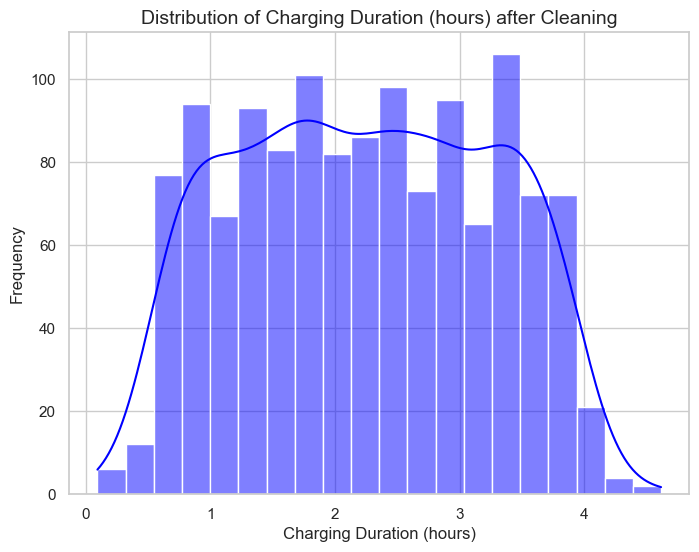

In [3]:
plt.figure(figsize=(8,6))
sns.histplot(valid_data['Charging Duration (hours)'], bins=20, kde=True, color='blue')
plt.title('Distribution of Charging Duration (hours) after Cleaning', fontsize=14)
plt.xlabel('Charging Duration (hours)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Scatter Plot: Energy Consumed vs Charging Duration

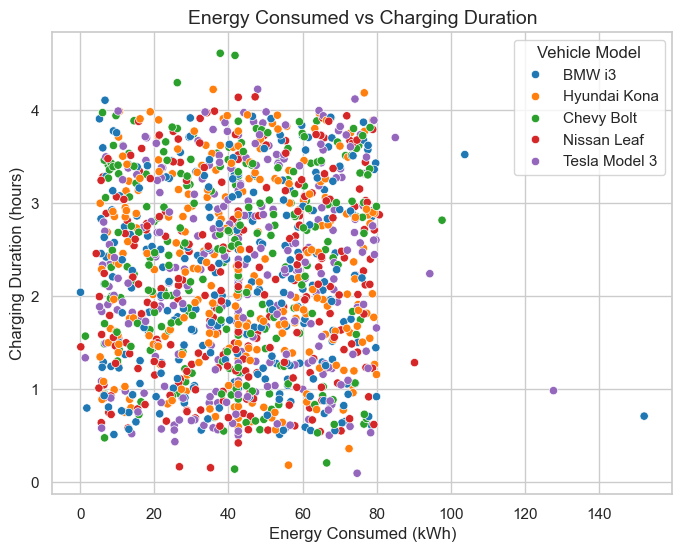

In [4]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=valid_data['Energy Consumed (kWh)'], y=valid_data['Charging Duration (hours)'], hue=vehicle_model_column, palette='tab10')
plt.title('Energy Consumed vs Charging Duration', fontsize=14)
plt.xlabel('Energy Consumed (kWh)')
plt.ylabel('Charging Duration (hours)')
plt.grid(True)
plt.show()

In [5]:
print(valid_data["Vehicle Model"].value_counts())
print()
print(vehicle_model_column.value_counts())


Vehicle Model
Tesla Model 3    278
Hyundai Kona     265
Nissan Leaf      257
BMW i3           256
Chevy Bolt       253
Name: count, dtype: int64

Vehicle Model
Tesla Model 3    278
Hyundai Kona     265
Nissan Leaf      257
BMW i3           256
Chevy Bolt       253
Name: count, dtype: int64


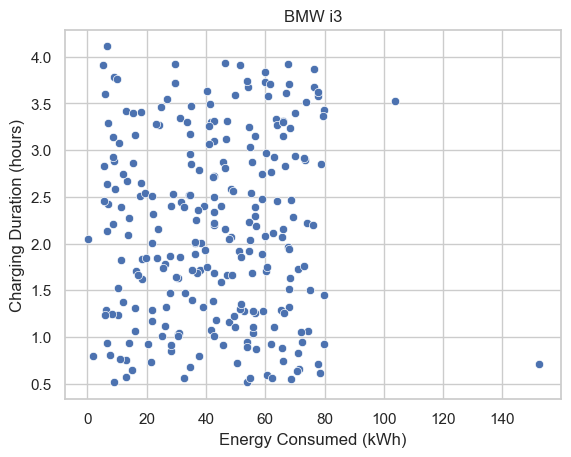

In [6]:
v = "BMW i3"   # or any of the others
sub = valid_data[valid_data["Vehicle Model"] == v].dropna(
    subset=['Energy Consumed (kWh)', 'Charging Duration (hours)']
)

sns.scatterplot(
    data=sub,
    x='Energy Consumed (kWh)',
    y='Charging Duration (hours)'
)
plt.title(v)
plt.grid(True)
plt.show()


Tesla Model 3 points plotted: 278
Nissan Leaf points plotted: 257
Hyundai Kona points plotted: 265
Chevy Bolt points plotted: 253
BMW i3 points plotted: 256


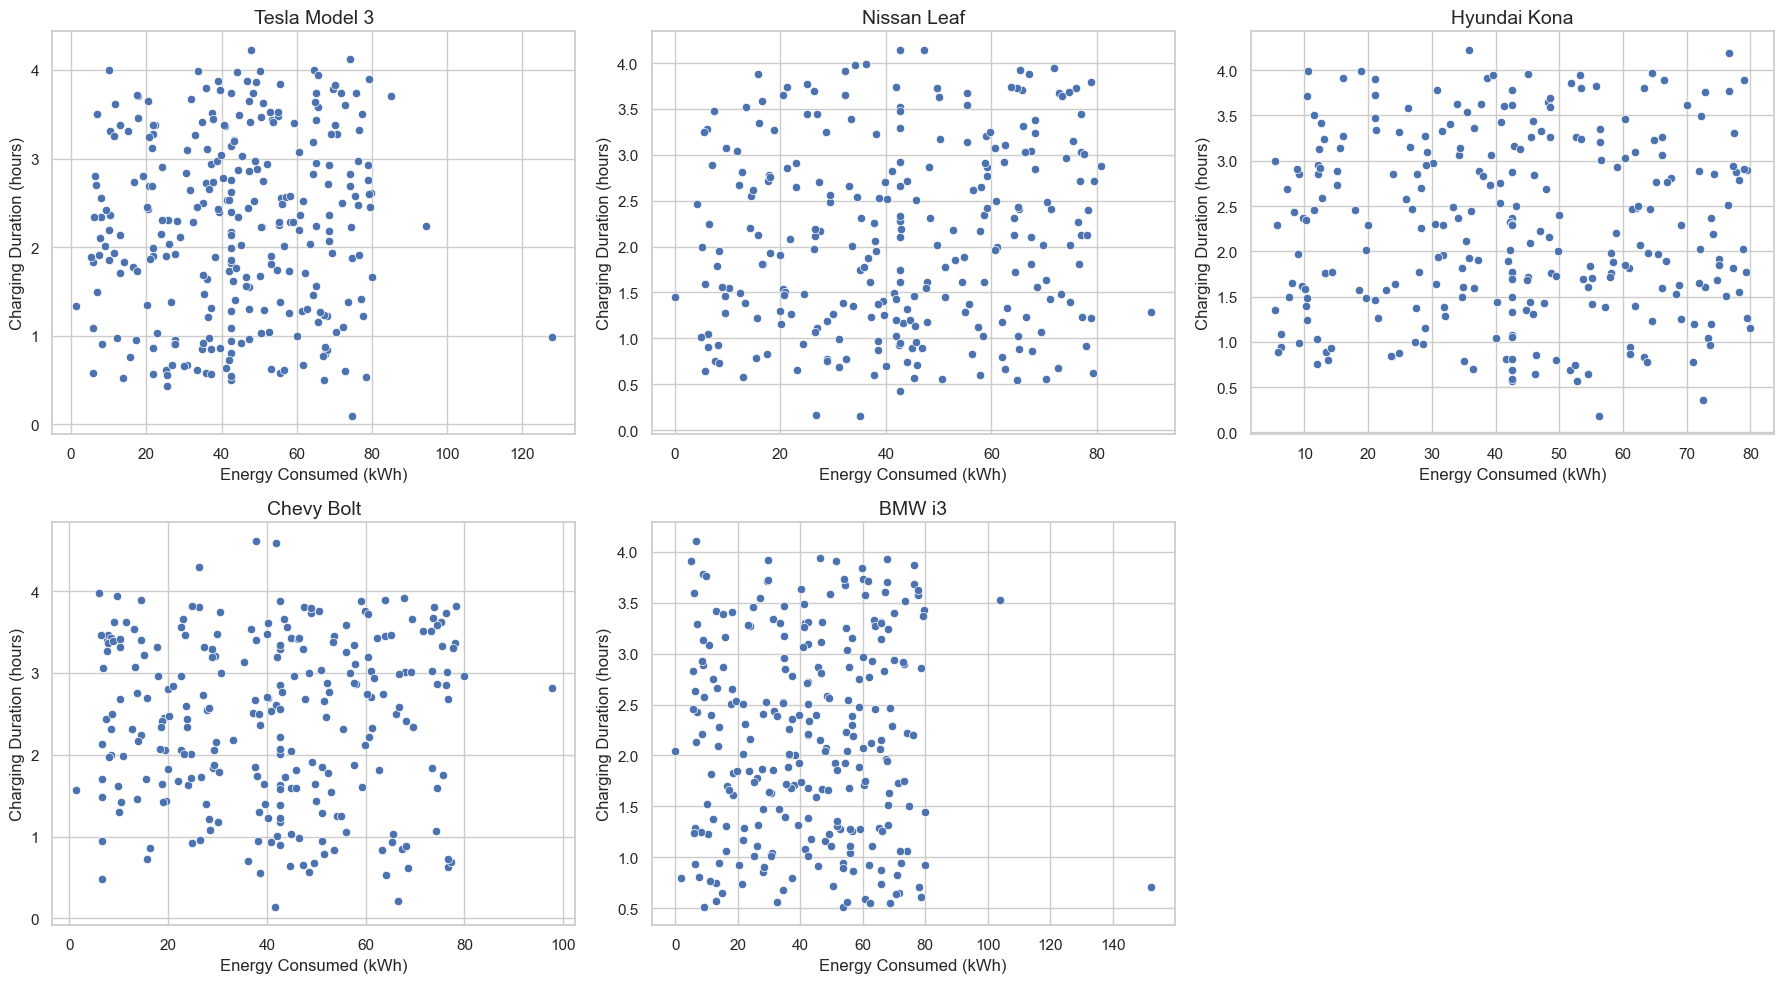

In [7]:
selected_vehicles = [
    'Tesla Model 3',
    'Nissan Leaf',
    'Hyundai Kona',
    'Chevy Bolt',   # exact name from the data
    'BMW i3'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, vehicle in enumerate(selected_vehicles):
    sub = valid_data[valid_data["Vehicle Model"] == vehicle].dropna(
        subset=['Energy Consumed (kWh)', 'Charging Duration (hours)']
    )

    print(vehicle, "points plotted:", len(sub))  # sanity check in console

    sns.scatterplot(
        data=sub,
        x='Energy Consumed (kWh)',
        y='Charging Duration (hours)',
        ax=axes[idx]
    )

    axes[idx].set_title(vehicle, fontsize=14)
    axes[idx].set_xlabel('Energy Consumed (kWh)')
    axes[idx].set_ylabel('Charging Duration (hours)')
    axes[idx].grid(True)

# Hide any unused subplots (only last one in your case)
for j in range(len(selected_vehicles), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


Scatter plots of energy consumed versus charging duration, disaggregated by vehicle model, show a broadly consistent positive relationship across all five EVs: longer sessions tend to deliver more energy. However, the large spread in kWh for a given duration suggests that charging duration alone is an incomplete predictor of energy consumption. Models such as the Tesla Model 3 and BMW i3 exhibit higher maximum session energies than the Hyundai Kona, Nissan Leaf and Bolt, which is likely related to differences in battery capacity and user charging behaviour. Overall, vehicle model appears to influence the range of energy per session, but not the fundamental energy–duration pattern.

# Key Takeaways:
✅ Different battery capacities: Tesla Model 3 clearly has larger capacity (extends to 120 kWh)
✅ Vehicle-specific behavior: Each model shows slightly different patterns, validating the need to include vehicle model as a feature in ML models
✅ Outliers vary by vehicle: Chevy Bolt has more extreme duration outliers; BMWi3 has energy outliers
✅ Data heterogeity confirmed: Even within individual vehicle nodels, there's substantial variability - reinforcing the need for ML modelling 

In [8]:
print(valid_data.columns)
print('Battery_Capacity_Quantile' in valid_data.columns)


Index(['User ID', 'Vehicle Model', 'Battery Capacity (kWh)',
       'Charging Station ID', 'Charging Station Location',
       'Charging Start Time', 'Charging End Time', 'Energy Consumed (kWh)',
       'Charging Duration (hours)', 'Charging Rate (kW)',
       'Charging Cost (USD)', 'Time of Day', 'Day of Week',
       'State of Charge (Start %)', 'State of Charge (End %)',
       'Distance Driven (since last charge) (km)', 'Temperature (°C)',
       'Vehicle Age (years)', 'Charger Type', 'User Type',
       'Charging Start Hour', 'Charging Start Day', 'Charging Start Month'],
      dtype='object')
False


In [9]:
# Create quantile bins for Battery Capacity
valid_data['Battery_Capacity_Quantile'] = pd.qcut(valid_data['Battery Capacity (kWh)'],
                                                  q=4,
                                                  labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])

# Display quantile ranges 
print("Battery Capacity Quantile Ranges:")
print(valid_data.groupby('Battery_Capacity_Quantile')['Battery Capacity (kWh)'].agg(['min', 'max', 'count']))
print()

Battery Capacity Quantile Ranges:
                                 min         max  count
Battery_Capacity_Quantile                              
Q1 (Lowest)                 1.532807   62.000000    516
Q2                         63.096317   75.000000    258
Q3                         76.336591   85.000000    252
Q4 (Highest)               86.092480  193.003074    283



C:\Users\mehaz\AppData\Local\Temp\ipykernel_60092\2207111005.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(valid_data.groupby('Battery_Capacity_Quantile')['Battery Capacity (kWh)'].agg(['min', 'max', 'count']))


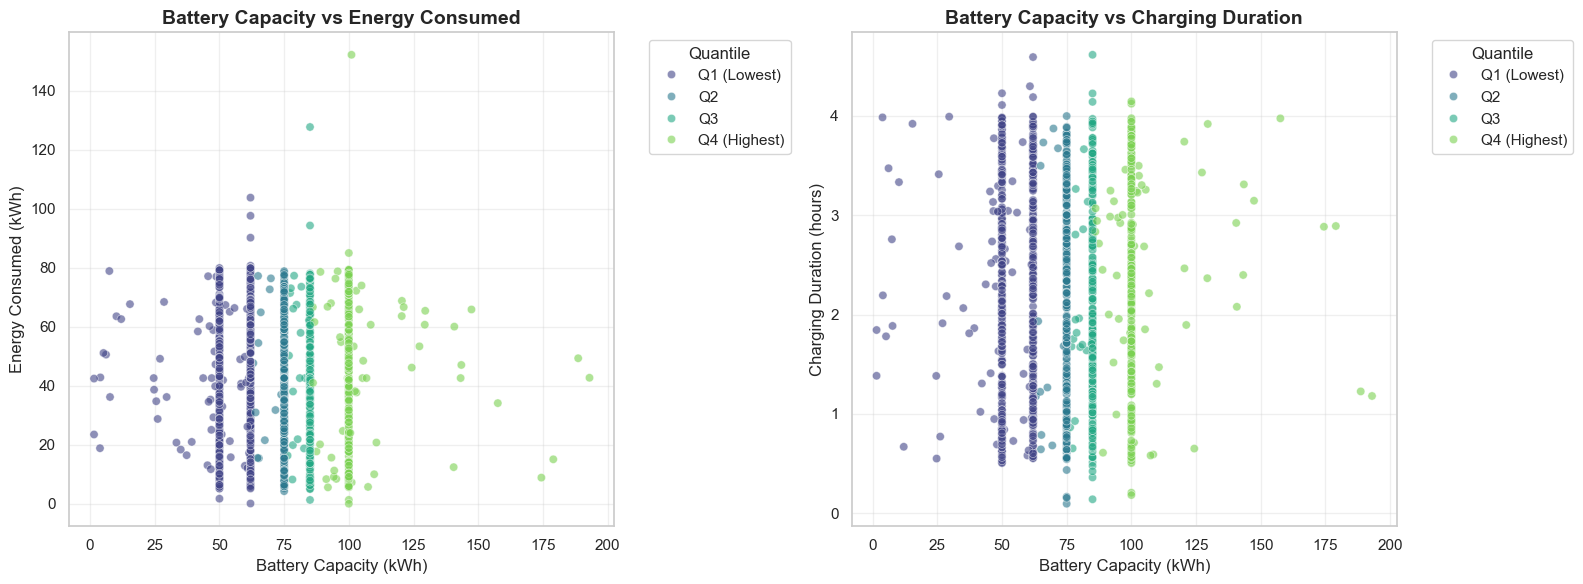

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Energy Consumed vs Battery Capacity (colored by quantile)
sns.scatterplot(data=valid_data,
                x='Battery Capacity (kWh)',
                y='Energy Consumed (kWh)',
                hue='Battery_Capacity_Quantile',
                palette='viridis',
                alpha=0.6,
                ax=axes[0])
axes[0].set_title('Battery Capacity vs Energy Consumed', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Battery Capacity (kWh)')
axes[0].set_ylabel('Energy Consumed (kWh)')
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Quantile', bbox_to_anchor=(1.05, 1), loc='upper left')

# Battery Capacity vs Charging Duration (colored by quantile)
sns.scatterplot(data=valid_data, 
                x='Battery Capacity (kWh)', 
                y='Charging Duration (hours)', 
                hue='Battery_Capacity_Quantile',
                palette='viridis',
                alpha=0.6,
                ax=axes[1])
axes[1].set_title('Battery Capacity vs Charging Duration', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Battery Capacity (kWh)')
axes[1].set_ylabel('Charging Duration (hours)')
axes[1].grid(True, alpha=0.3)
axes[1].legend(title='Quantile', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Battery capacity vs Energy Consumed (left)

- There's an upper envelop that increases with capacity:
    - Small packs (Q1, left side) rarely consume huge energy per session.
    - Larger packs (Q3-Q4) occasionally show very high energy sessions (80+ kWh).
    - So: bigger battery -> can take more energy in a single session.
- But the typical energy used overlaps a lot across quartiles:
    - Many Q4 (largest battery) sessions still sit around 20-60 kWh, similar to Q2-Q3.
    - User don't always charge the big battery close to "empty -> full".

Takeaway:
Battery capacity mainly affects the ceiling of how much energy can be delivered in a session, but typical session energies overlap strongly across capacity quartiles. Drives with large batteries often perform partial charges rather than alwys using the full capacity.

# Battery capacity vs Charging Duration (right)
- Most points for all quartiles lie in roughly 0.5-4 hours.
- Q4(largest batteries) do not suddenly jump to 6-8 hour charges.
- There may be a slight trend that higher-capacity vehicles have somewhat more sessions above ~3 hours, but it's weak compared to the spread.

Takeaway:
Charging time does not scale strongly with battery size. People with larger batteries don't charge proportionally longer. They either:
 - charge at higher power (fast chargers)
 - do partial charges

 ✅Summary:
 Stratifying sessions by battery capacity quartiles shows that larger battery packs allow higher maximum delivered energy per session, but the distribution of typical energy and especially charging duration overlaps strongly across all quartiles. In other words, battery size sets a technical upper bound on possible session energy, but actual charging behaviour (how long drivers stay plugged in and how much they choose to recharge) is only weakly driven by battery capacity and likely influenced more by usage patterns, initial state-of-charge and charger power

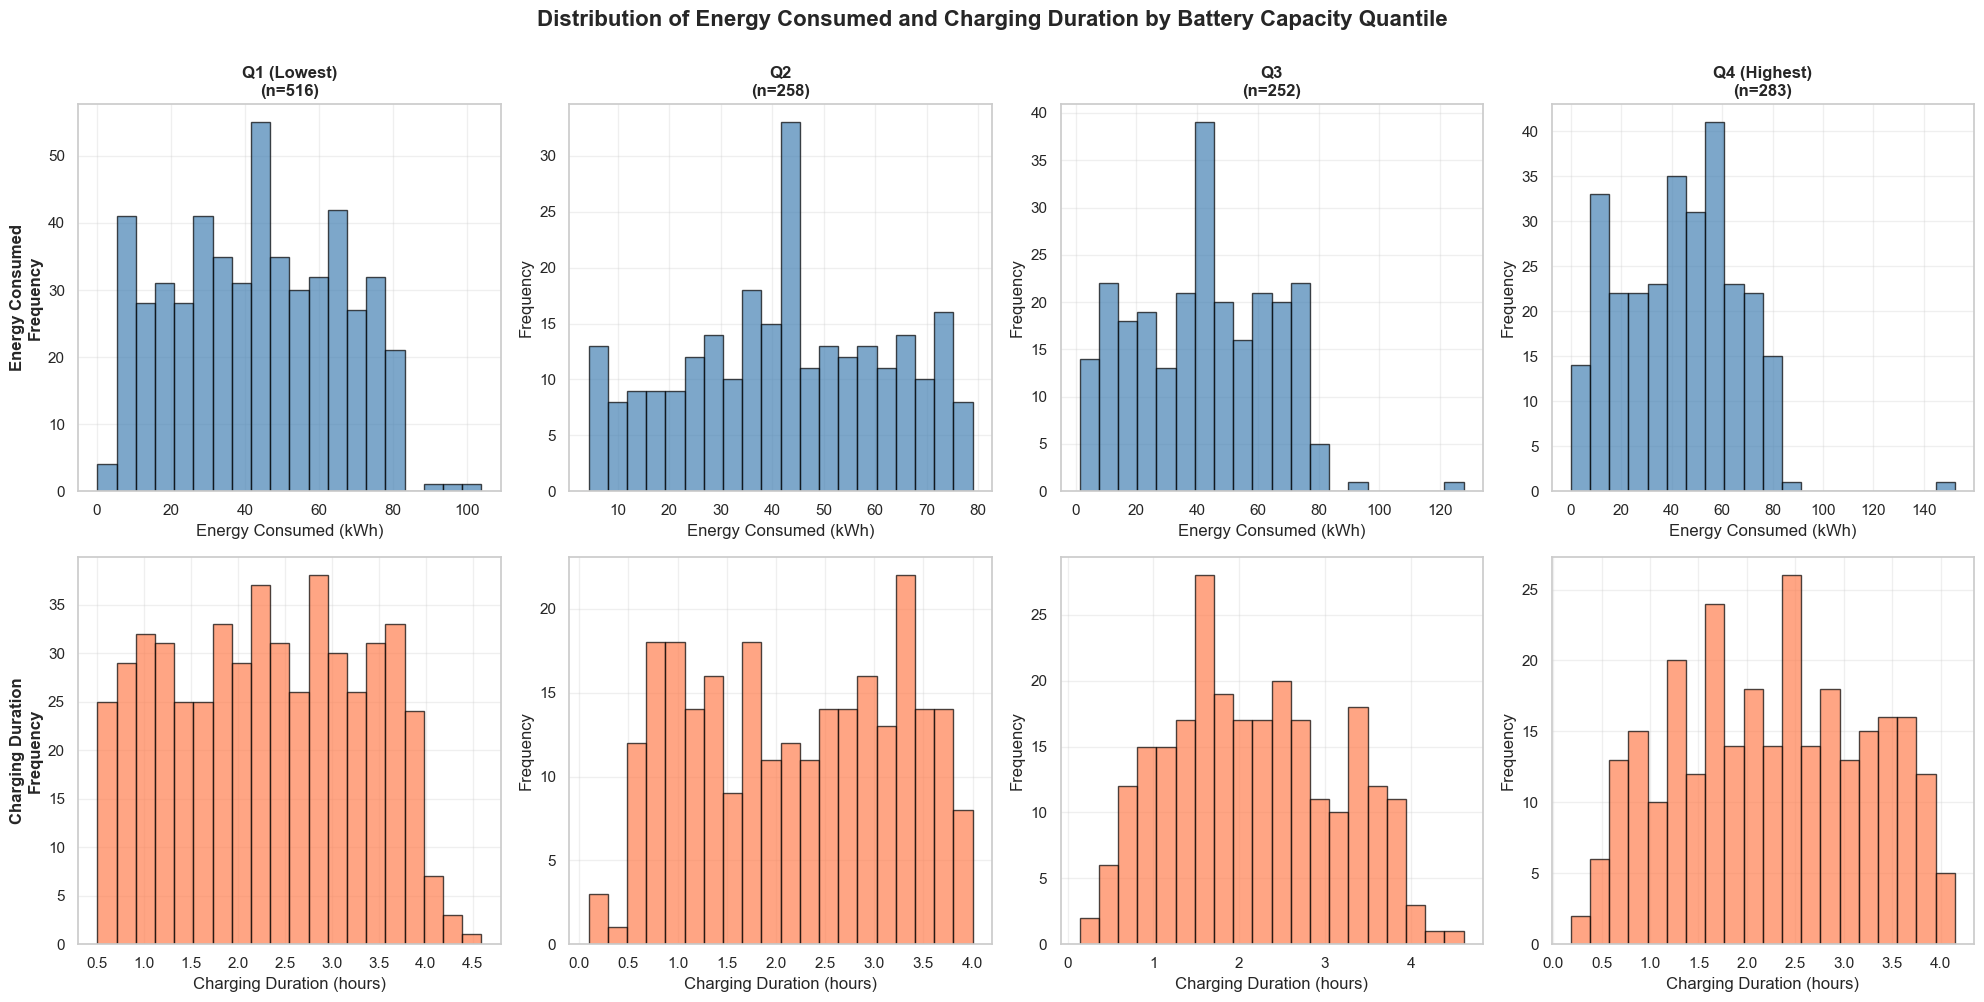

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

quantiles = ['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']

for idx, quantile in enumerate(quantiles):
    quantile_data = valid_data[valid_data['Battery_Capacity_Quantile'] == quantile]
    
    # Energy Consumed histogram
    axes[0, idx].hist(quantile_data['Energy Consumed (kWh)'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, idx].set_title(f'{quantile}\n(n={len(quantile_data)})', fontsize=12, fontweight='bold')
    axes[0, idx].set_xlabel('Energy Consumed (kWh)')
    axes[0, idx].set_ylabel('Frequency')
    axes[0, idx].grid(True, alpha=0.3)
    
    # Charging Duration histogram
    axes[1, idx].hist(quantile_data['Charging Duration (hours)'], bins=20, color='coral', edgecolor='black', alpha=0.7)
    axes[1, idx].set_xlabel('Charging Duration (hours)')
    axes[1, idx].set_ylabel('Frequency')
    axes[1, idx].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Energy Consumed\nFrequency', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Charging Duration\nFrequency', fontsize=12, fontweight='bold')

fig.suptitle('Distribution of Energy Consumed and Charging Duration by Battery Capacity Quantile', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Top row - Energy Consumed (kWh) by battery-capacity quartile
Each top histogram shows how much energy is delivered per session for cars in that battery-capacity group
- Right-shift as capacity increases 
- Overlapping. but different ceilings

Takeaway:
Battery capacity is positively associated with session energy - larger batteries tend to have higher typical and maximum kWh per charge. But the overlap shows that many drivers with big batteries still do partial chargers in the same range as small-battery cars.

# Bottom row - Charging Duration (hours) by quartile
Takeaway:
Charging time is similar across all battery sizes. Drivers with big batteries are not simply charging for much longer; instead they:
    - often do partial charges
    - charge at higher power (fast charges).

Battery size doesn't strongly dictate how long a car is plugged in.

# Summary 
Figure X shows the distributions of session energy and charging duration, stratified by battery-capacity quartiles. Higher-capacity vehicles (Q3–Q4) exhibit a noticeable right-shift in energy consumption, with higher typical and maximum kWh per session and occasional very high-energy charges (>80 kWh). In contrast, the charging-duration distributions remain broadly similar across all quartiles, with most sessions lasting between 0.5 and 4 hours. This suggests that battery capacity mainly affects the amount of energy delivered per session, while charging duration is driven more by user behaviour and charging power than by battery size alone.

## Charging Duration by Time of Day (assuming 'Time of Day')

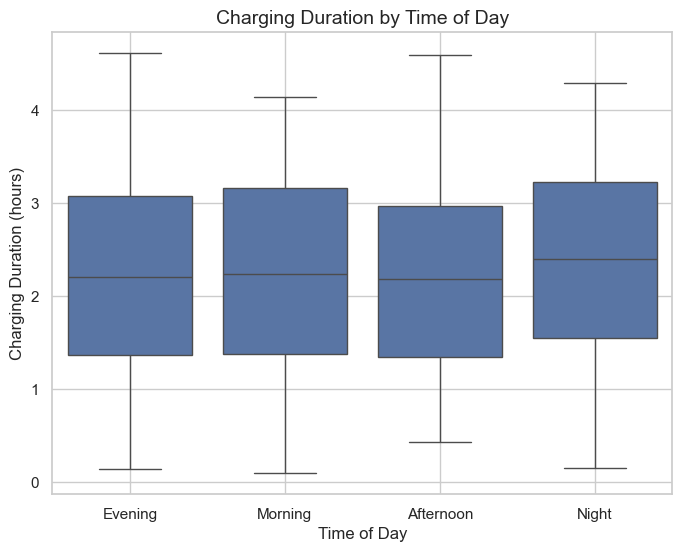

In [12]:
if 'Time of Day' in valid_data.columns:
    plt.figure(figsize=(8,6))
    sns.boxplot(x='Time of Day', y='Charging Duration (hours)', data=valid_data)
    plt.title('Charging Duration by Time of Day', fontsize=14)
    plt.xlabel('Time of Day')
    plt.ylabel('Charging Duration (hours)')
    plt.grid(True)
    plt.show()

## Correlation Heatmap

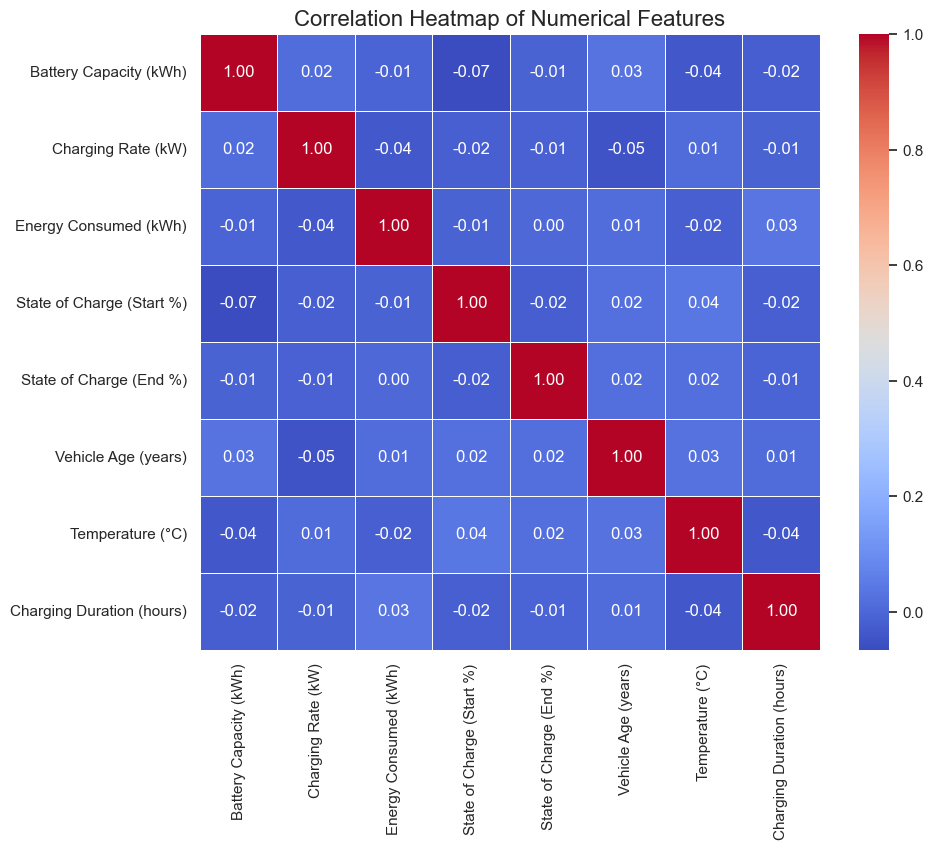

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt


numerical_features = valid_data[['Battery Capacity (kWh)', 'Charging Rate (kW)',
                                 'Energy Consumed (kWh)', 'State of Charge (Start %)',
                                 'State of Charge (End %)', 'Vehicle Age (years)',
                                 'Temperature (°C)', 'Charging Duration (hours)']]


corr_matrix = numerical_features.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

Very Weak Correlations Overall Almost all correlations are close to zero (light blue color) The strongest correlations are barely above 0.04 in absolute value This indicates features are largely independent of each other.

Very Weak Correlations Overall Almost all correlations are close to zero (light blue color) The strongest correlations are barely above 0.04 in absolute value This indicates features are largely independent of each other. (Random Forest, XGBoost) will capture these better than linear regression.

C:\Users\mehaz\AppData\Local\Temp\ipykernel_60092\250714691.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=valid_data, x='Charger Type',  # Replace with your actual column name


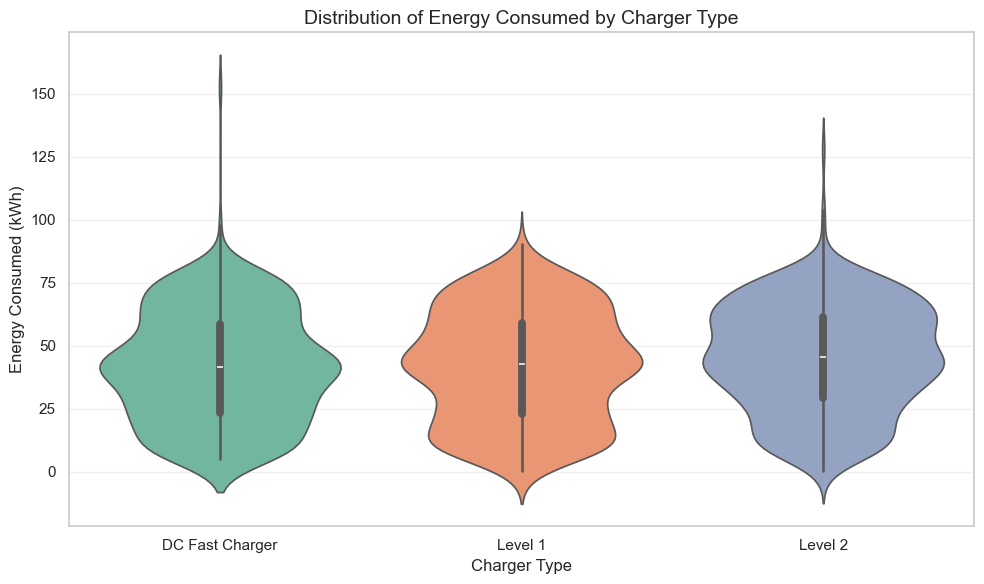

In [14]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=valid_data, x='Charger Type',  # Replace with your actual column name
               y='Energy Consumed (kWh)', 
               palette='Set2')
plt.title('Distribution of Energy Consumed by Charger Type', fontsize=14)
plt.xlabel('Charger Type')
plt.ylabel('Energy Consumed (kWh)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# (Violin plot) Energy Consumed (kWh) for each Charger Type:
- Width of the violin at a given height = how many sessions have that energy.
- White dot/ thick bar in the centre (if enabled) = median/ IQR.
- Vertical extend = overall min-max range (incl. outliers).

From what i can see:
1. Medans are quite similar
 - All the charger types sit roughly around 40 - 50 kWh per session.
 - No huge shift in "typical" energy per session between Level 1, Level 2 and DC

2. Spread is large for all charger types 
 - Energy ranges from very small (~0-10 kWh) up to pretty large value (70+ kWh, with a few extreme outliers > 120 kWh)
 - Charging behaviour is highly variable regardless of charger type.

3. DC Fast seems to have more extreme high values
 - The DC Fast violin looks slightly “fatter” and may have a few more very high-energy sessions compared with Level 1/2.
 - This fits the idea that fast chargers are sometimes used for big top-ups, but it’s not a dramatic separation.

 Takeaway:
 - Figure X shows the distribution of energy consumed per session by charger type.
   All three charger categories (Level 1, Level 2, DC fast) exhibit broadly similar median energy consumption around 40–50 kWh, with substantial spread. DC fast chargers show slightly more high-energy sessions, but overall the distributions overlap strongly. This suggests that, in this synthetic dataset, charger type does not strongly separate typical energy per session, even though fast chargers may be used for some larger charging events.

Heterogeneity (Variability) All three show high variability - the wide, bulbous shapes indicate diverse energy consumption patterns This heterogeneity is important because it means:

Simple averages won't capture the complexity ML models are necessary to predict energy consumption accurately Different factors (vehicle model, battery size, charging duration, etc.) likely influence the outcome

## Feature Engineering 

In [15]:
# Add new features to the dataset
valid_data['Charging Efficiency (kWh/h)'] = valid_data['Energy Consumed (kWh)'] / valid_data['Charging Duration (hours)']

valid_data['Energy per Charge %'] = valid_data['Energy Consumed (kWh)'] / \
                                    (valid_data['State of Charge (End %)'] - valid_data['State of Charge (Start %)'])

valid_data['Distance per kWh'] = valid_data['Distance Driven (since last charge) (km)'] / valid_data['Energy Consumed (kWh)']

valid_data['Total Charge Gained'] = valid_data['State of Charge (End %)'] - valid_data['State of Charge (Start %)']

valid_data['Charger Efficiency'] = valid_data['Charging Rate (kW)'] / valid_data['Charging Duration (hours)']

# Handle division by zero or infinity values
#valid_data.replace([np.inf, -np.inf], np.nan, inplace=True)
#valid_data.fillna(0, inplace=True)  # Replace NaN or infinity with 0 for simplicity

# For Temperature Adjusted Consumption, assuming 20°C as the "average" comfortable temperature for EVs
average_temperature = 20
valid_data['Temperature Adjusted Consumption'] = valid_data['Energy Consumed (kWh)'] * \
                                                 (1 + abs(valid_data['Temperature (°C)'] - average_temperature) / average_temperature)

# Check if new features are added
valid_data.head()

,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),...,Charging Start Hour,Charging Start Day,Charging Start Month,Battery_Capacity_Quantile,Charging Efficiency (kWh/h),Energy per Charge %,Distance per kWh,Total Charge Gained,Charger Efficiency,Temperature Adjusted Consumption
0,User_1,BMW i3,108.463007,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712346,0.591363,36.389181,...,0,Monday,1,Q4 (Highest),102.665033,1.069851,4.835954,56.748386,61.534378,84.839289
1,User_2,Hyundai Kona,100.000000,Station_428,San Francisco,2024-01-01 01:00:00,2024-01-01 03:01:00,12.339275,3.133652,30.677735,...,1,Monday,1,Q4 (Highest),3.937666,0.165520,9.085850,74.548566,9.789771,15.849166
2,User_3,Chevy Bolt,75.000000,Station_181,San Francisco,2024-01-01 02:00:00,2024-01-01 04:48:00,19.128876,2.452653,27.513593,...,2,Monday,1,Q2,7.799260,0.303330,3.753449,63.063011,11.217892,20.087234
3,User_4,Hyundai Kona,50.000000,Station_327,Houston,2024-01-01 03:00:00,2024-01-01 06:42:00,79.457824,1.266431,32.882870,...,3,Monday,1,Q1 (Lowest),62.741544,4.814364,2.511745,16.504325,25.964995,152.226543
4,User_5,Hyundai Kona,50.000000,Station_108,Los Angeles,2024-01-01 04:00:00,2024-01-01 05:46:00,19.629104,2.019765,10.215712,...,4,Monday,1,Q1 (Lowest),9.718509,2.069525,10.375504,9.484836,5.057871,46.947124


In [16]:
valid_data['Charging Efficiency (kWh/h)'] = \
    valid_data['Energy Consumed (kWh)'] / valid_data['Charging Duration (hours)']

valid_data['Energy per Charge %'] = (
    valid_data['Energy Consumed (kWh)'] /
    (valid_data['State of Charge (End %)'] - valid_data['State of Charge (Start %)'])
)
valid_data['Distance per kWh'] = \
    valid_data['Distance Driven (since last charge) (km)'] / valid_data['Energy Consumed (kWh)']

valid_data['Total Charge Gained'] = \
    valid_data['State of Charge (End %)'] - valid_data['State of Charge (Start %)']

valid_data['Charger Efficiency'] = valid_data['Charging Rate (kW)'] / valid_data['Charging Duration (hours)']

average_temperature = 20
valid_data['Temperature Adjusted Consumption'] = valid_data['Energy Consumed (kWh)'] * \
    (1 + abs(valid_data['Temperature (°C)'] - average_temperature)/average_temperature)

# Check if new features are added
valid_data.head()

,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),...,Charging Start Hour,Charging Start Day,Charging Start Month,Battery_Capacity_Quantile,Charging Efficiency (kWh/h),Energy per Charge %,Distance per kWh,Total Charge Gained,Charger Efficiency,Temperature Adjusted Consumption
0,User_1,BMW i3,108.463007,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712346,0.591363,36.389181,...,0,Monday,1,Q4 (Highest),102.665033,1.069851,4.835954,56.748386,61.534378,84.839289
1,User_2,Hyundai Kona,100.000000,Station_428,San Francisco,2024-01-01 01:00:00,2024-01-01 03:01:00,12.339275,3.133652,30.677735,...,1,Monday,1,Q4 (Highest),3.937666,0.165520,9.085850,74.548566,9.789771,15.849166
2,User_3,Chevy Bolt,75.000000,Station_181,San Francisco,2024-01-01 02:00:00,2024-01-01 04:48:00,19.128876,2.452653,27.513593,...,2,Monday,1,Q2,7.799260,0.303330,3.753449,63.063011,11.217892,20.087234
3,User_4,Hyundai Kona,50.000000,Station_327,Houston,2024-01-01 03:00:00,2024-01-01 06:42:00,79.457824,1.266431,32.882870,...,3,Monday,1,Q1 (Lowest),62.741544,4.814364,2.511745,16.504325,25.964995,152.226543
4,User_5,Hyundai Kona,50.000000,Station_108,Los Angeles,2024-01-01 04:00:00,2024-01-01 05:46:00,19.629104,2.019765,10.215712,...,4,Monday,1,Q1 (Lowest),9.718509,2.069525,10.375504,9.484836,5.057871,46.947124


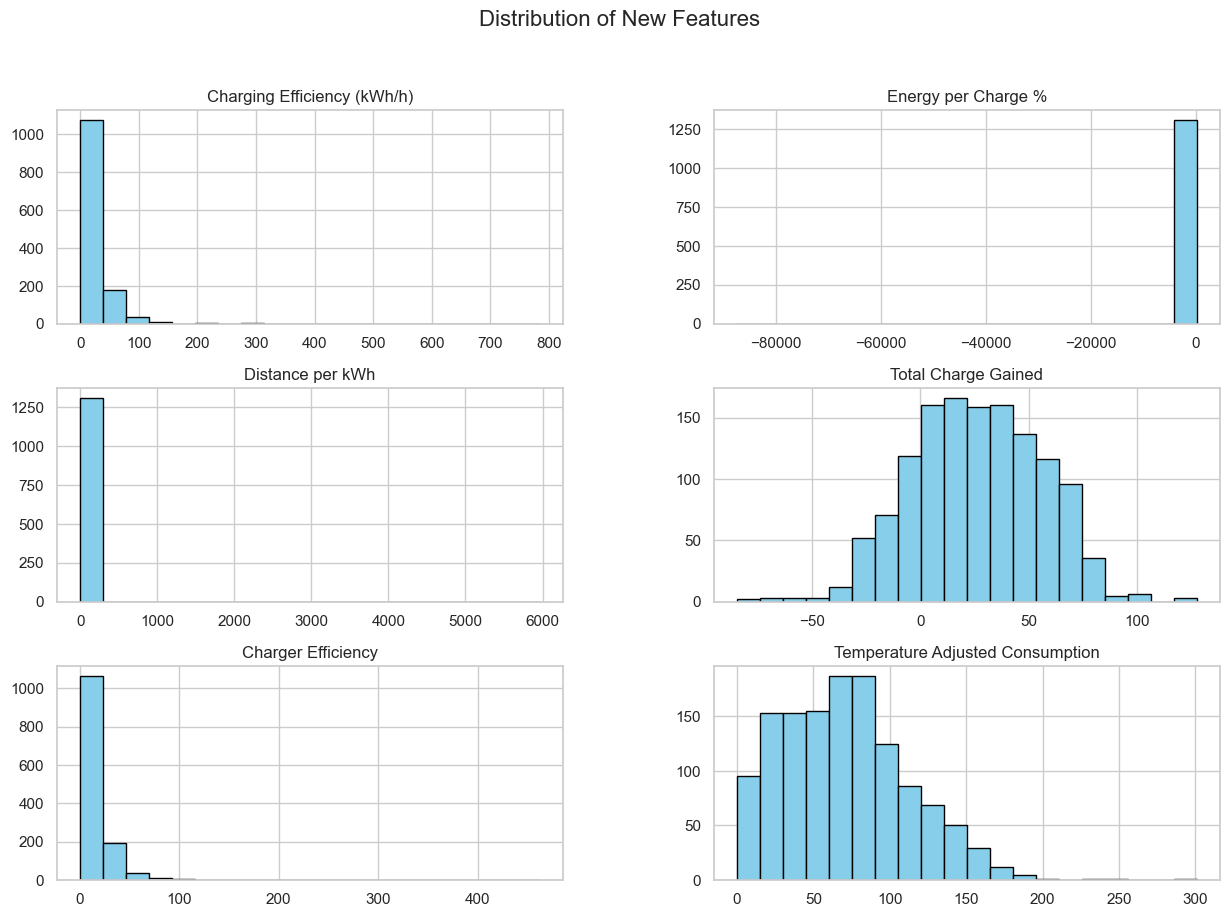

In [17]:
import matplotlib.pyplot as plt

# Visualize the distribution of new features
new_features = ['Charging Efficiency (kWh/h)', 'Energy per Charge %',
                'Distance per kWh', 'Total Charge Gained',
                'Charger Efficiency', 'Temperature Adjusted Consumption']

# Plot histograms for new features
valid_data[new_features].hist(bins=20, figsize=(15,10), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of New Features', fontsize=16)
plt.show()

1. Charging Efficiency (kWh/h)

Most values are crammed into the left side (small kWh/h) with a long tail to the right.

That means most sessions have a similar, moderate average charging power, but there are some extreme sessions with very high kWh/h (probably very short charges that make the ratio explode or a few bad readings).

Interpretation: feature is strongly right-skewed and has outliers → good candidate for clipping or a log transform before modelling.

2. Energy per Charge %

x-axis goes far into the negative and almost all the bars are near 0.

Physically, “energy per charge %” should probably be between 0 and 100 % (or at least non-negative).

Big negative values → almost certainly data or formula issues (e.g. SoC_end < SoC_start, swapped columns, meter reset, etc.), or divisions by very small numbers.

Interpretation: this feature in its current form is not trustworthy. You should:

Inspect a few rows with extreme negatives.

Decide whether to fix the formula, drop those rows, or drop the feature.

3. Distance per kWh

Again, everything is squeezed near 0 with an axis going out to thousands.

In reality you expect something like maybe a few km/kWh, not thousands.

Huge values usually mean energy in the denominator is almost zero or mis-logged sessions (e.g. distance not reset, or distance since last charge is wrong).

Interpretation: strong right skew + unrealistic outliers → needs cleaning (filter unrealistic values, maybe cap at a plausible max) or reconsider the definition.

4. Total Charge gained

This one looks closest to a nice bell-shaped distribution centered somewhere in the middle of the range.

A few negative and >100 values might exist, but bulk of data looks reasonable.

Interpretation:

Most sessions add a moderate amount of SoC, with fewer tiny or huge charges.

This is a well-behaved feature and likely useful for analysis and modelling with minimal transformation (maybe just standardize).

5. Charger Efficiency

Same story as (1): cluster at low–moderate values, long tail to the right.

If this is something like Energy into battery / Energy from grid, you would expect values roughly around 0.8–1.1, not hundreds.

Very high values again suggest divisions by tiny numbers or bad sessions.

Interpretation: meaningful in the middle, but outliers and skew mean you should:

Cap extreme values or remove physically impossible ones.

Possibly log-transform.

6. Temperature Adjusted Consumption

Unimodal but right-skewed: most data in a main hump, with a tail towards higher consumption.

That’s actually plausible: many trips have normal consumption; some have really high (cold weather, high speed, short trips).

Interpretation:

This feature makes physical sense and shows heterogeneity in how temperature impacts consumption.

For linear models, you might still scale/transform it, but you don’t have obvious data-quality disasters here.

# Relationships between new features and Charging Duration 

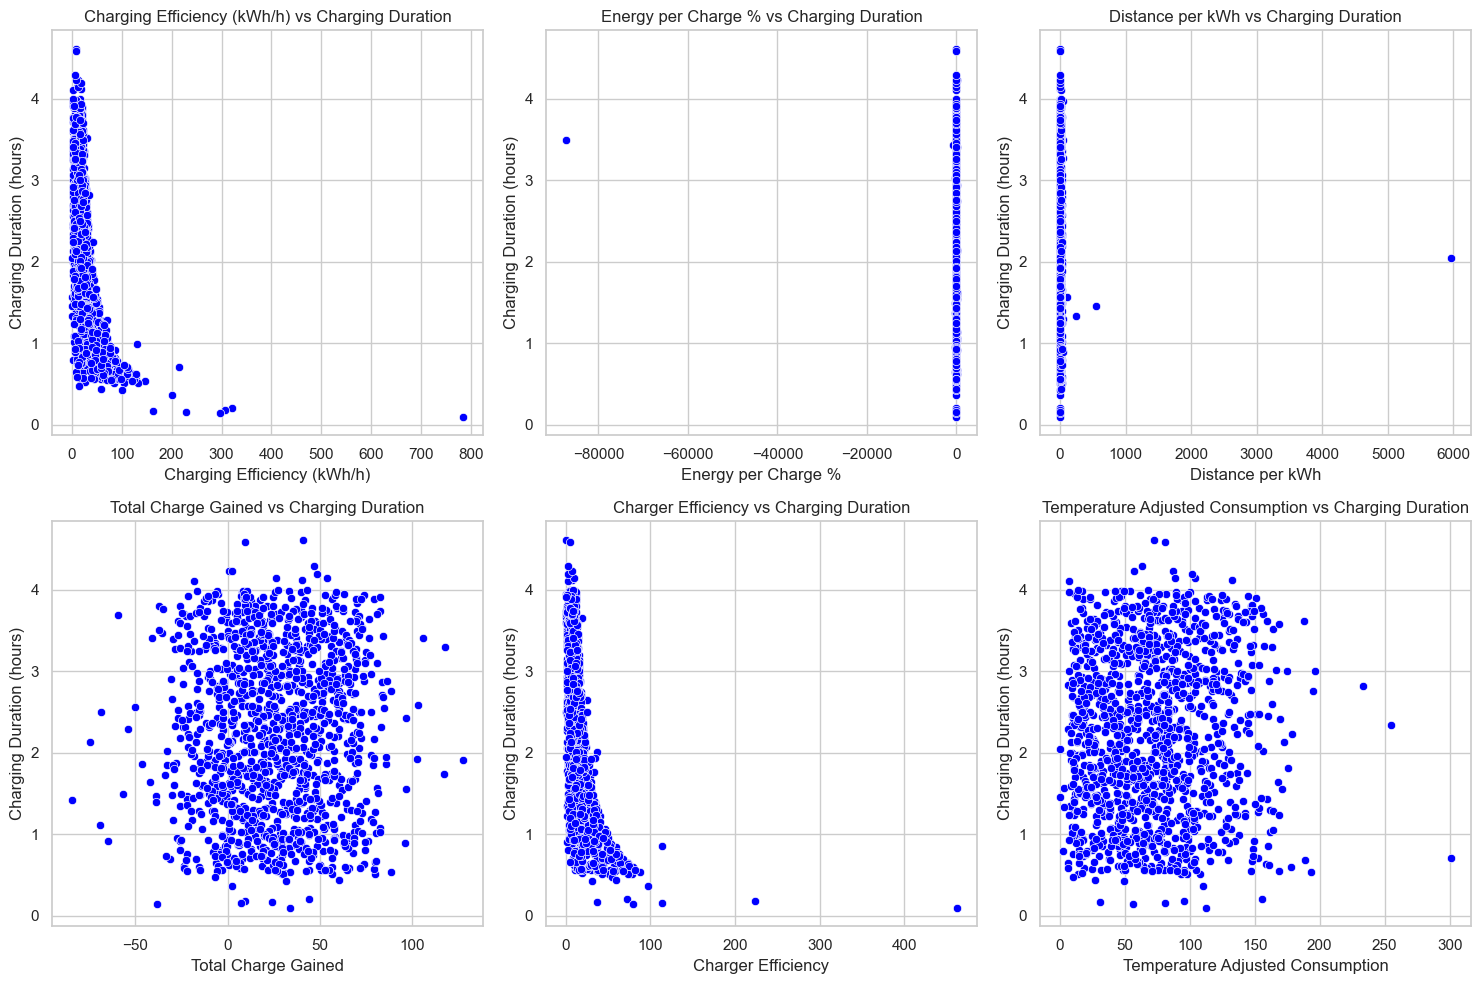

In [18]:
import seaborn as sns


plt.figure(figsize=(15,10))

for i, feature in enumerate(new_features, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=valid_data[feature], y=valid_data['Charging Duration (hours)'], color='blue')
    plt.title(f'{feature} vs Charging Duration', fontsize=12)
    plt.xlabel(feature)
    plt.ylabel('Charging Duration (hours)')

plt.tight_layout()
plt.show()

# How does this feature behave for short vs long duration sessions?

1. Charging Efficiency (kWh/h) vs Charging Duration 
- Reason: Efficiency = enrgy / duration
- Short, tiny changes produce artificially huge efficiencies 
- for longer sessions (>2-3h), efficiency stays in a lower band
- This feature is strongly affected by very short sessions and is partly redundant with duration itself

2. Energy per charge% vs Charging Duration
- Little evidence that session length systematically changes "energy per %"
- The huge negative point is almost certainly bad data or a brokem formula and should be investigated 

3. Distance per kWh vs Charging Duration
- Duration doesn’t seem to explain distance-per-kWh.

- The 6000 km/kWh point is not physically realistic → another data or formula issue.

4. Total Charge Gained vs Charging Duration 

- A big cloud of points spread across x and y.

- You might see a weak pattern: very long sessions can give higher total charge, but the relationship is noisy (some short sessions also have big charge gains).

Take-away:

- There is at best a weak positive relationship: longer sessions tend to gain more SoC, but it’s far from linear.

- This feature is not obviously determined just by duration – other factors (start SoC, battery size, driver behaviour) matter.

5. Temperature Adjusted Consumption vs Charging Duration 
- A fairly even cloud: wide range of consumption values for both short and long sessions.

- Maybe slightly more spread for very short durations, but no strong trend.

Take-away:

- Charging duration doesn’t strongly drive energy consumption per km; consumption is more about how and where the car was driven (speed, temperature, etc.) than how long the next charge took.


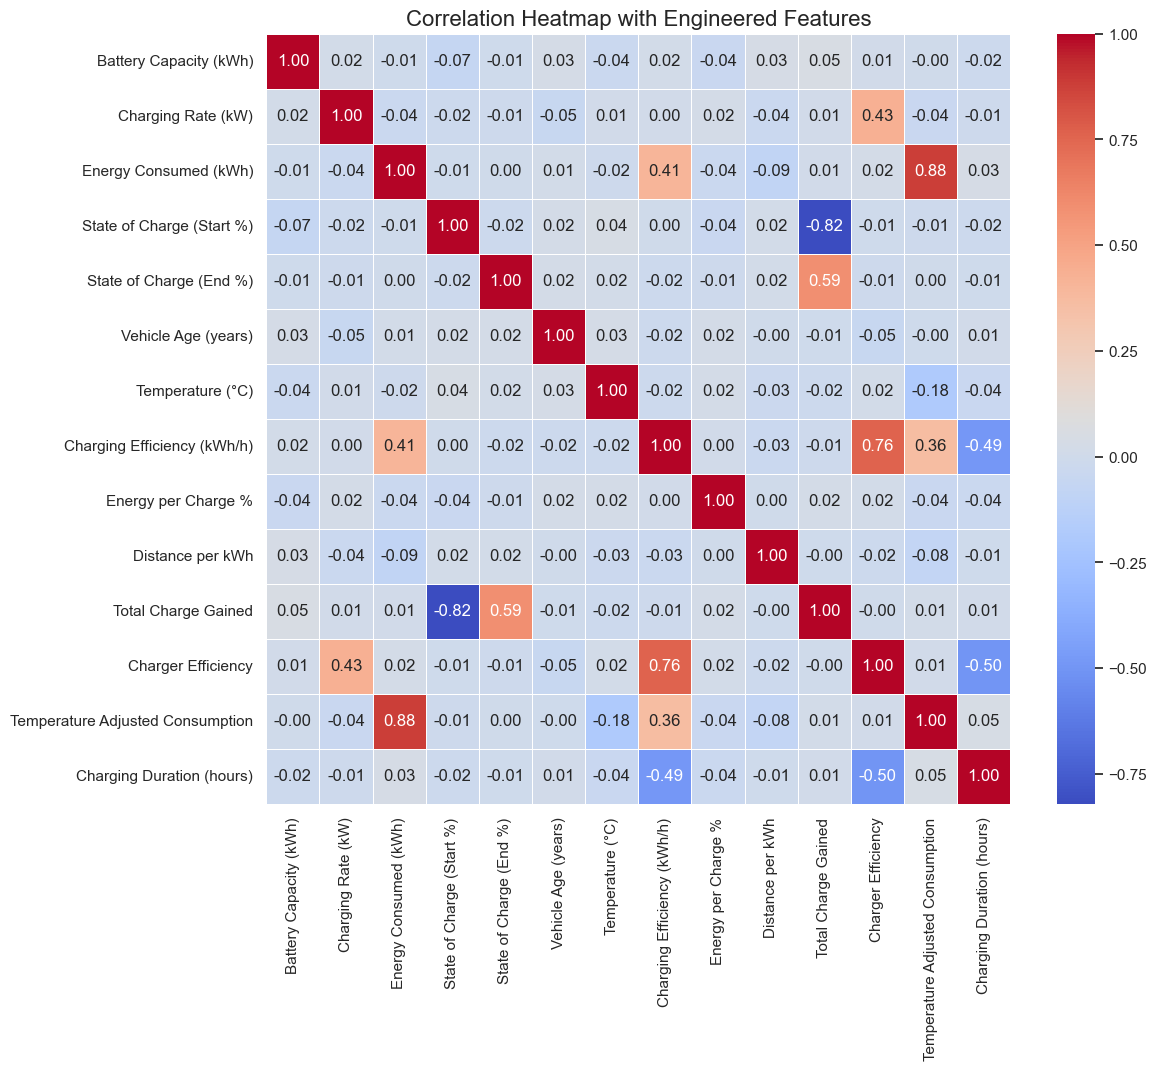

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

engineered_features = valid_data[['Battery Capacity (kWh)', 'Charging Rate (kW)',
                                  'Energy Consumed (kWh)', 'State of Charge (Start %)',
                                  'State of Charge (End %)', 'Vehicle Age (years)',
                                  'Temperature (°C)', 'Charging Efficiency (kWh/h)',
                                  'Energy per Charge %', 'Distance per kWh',
                                  'Total Charge Gained', 'Charger Efficiency',
                                  'Temperature Adjusted Consumption', 'Charging Duration (hours)']]

# Compute correlation matrix
corr_matrix = engineered_features.corr()

# Plot correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap with Engineered Features', fontsize=16)
plt.show()

## Correlation Heat Map 
# "Which of my features move together (positively or negatively), and which are basically independent?"

1. Most features are almost uncorrelated 
2. Pairs with strong relationships:
    - State of Charge (Start %) vs Total Charge Gained: -0.82
        - If start at high SoC, you can't gain much -> strong -ve correlation
        - very intuitive and confirms that 'Total Charge Gained' is behaving sensibly.
    - State of Charge (End %) vs Total Charge gained: +0.59
        - Sessions that end at higher SoC usually gained more charge
    - Energy Consumed (kWh) vs Temperature Adjusted Consumption: +0.88
        - Not surprising: this adjusted-consumption feature is built from energy use, so they are almost the same information 
        - For lineal models, one of them is enough 
    - Charging Efficiency (kWh/h) vs Charger Efficiency: +0.76
        - These two engineered “efficiency” metrics are also very similar: when one is high, the other tends to be high.
        - Again, likely redundant in a simple model.
3. Summary:
Clusters of highly related features are discovered:
- {Energy Consumed, Temperature Adjusted Consumption}
- {Charging Efficiency, Charger Efficiency}
- {SoC Start, SoC End, Total Charge Gained}

4.  What relates to Charging Duration (hours)?

Look at the last row/column:

Charging Duration vs Charging Efficiency: –0.49

Charging Duration vs Charger Efficiency: –0.50

Interpretation:

By construction, efficiency ≈ energy / duration.

For a given energy, shorter sessions ⇒ higher “kWh per hour”, so you get a moderate negative correlation.

Apart from that, duration has very weak correlation with everything else (battery size, SoC, temperature, etc.).
→ Charging time is influenced by several factors and not linearly dominated by any single one.

So for predicting Charging Duration you will likely need multiple features and maybe non-linear models, not just one strong predictor.

4. Features that look noisy / unhelpful (in this form)

Energy per Charge % and Distance per kWh show tiny correlations with almost everything. Combined with the earlier extreme outliers, this suggests:

Either there’s no simple linear relationship,

Or the features are too noisy / badly scaled right now.

They might still be useful in non-linear models, but from a linear-correlation perspective they don’t explain much.

5. Modelling Implications:
From this heatmap you can already conclude:

Check for redundancy / multicollinearity

For linear models, consider dropping one of each highly correlated pair (e.g. keep Energy Consumed, drop Temperature Adjusted Consumption, or vice versa; keep one of the efficiency metrics).

Don’t expect a simple linear rule for charging duration

No feature has |corr| > 0.5 with Charging Duration. You’ll likely need:

Several predictors together, and/or

Tree-based or non-linear models.

Your engineered features mostly behave sensibly

The strong correlations around SoC and charge gained match domain intuition, which is a good sanity check on your feature engineering.

## Model & Evaluation

In [20]:
# Normalize numerical columns 
from sklearn.preprocessing import StandardScaler

# Columns that might need scaling
from sklearn.preprocessing import StandardScaler

# Columns that might need scaling
# You’re saying: “These are the numeric columns whose scale I want to normalize.”
# Some are in kWh, some in hours, %, °C, km, etc. Right now they are on very different ranges.
columns_to_scale = ['Energy Consumed (kWh)', 'Charging Duration (hours)',
                    'Charging Rate (kW)', 'Charging Cost (USD)',
                    'State of Charge (Start %)', 'State of Charge (End %)','Total Charge Gained','Charger Efficiency','Charging Efficiency (kWh/h)',
                    'Distance Driven (since last charge) (km)', 'Temperature (°C)','Energy per Charge %','Distance per kWh',
                    'Vehicle Age (years)']

scaler = StandardScaler()
valid_data[columns_to_scale] = scaler.fit_transform(valid_data[columns_to_scale])

# Handle categorical data

# valid_data = pd.get_dummies(valid_data, columns=['Charger Type', 'User Type', 'Vehicle Model', 'Charging Station Location'])

print(valid_data.head())

  User ID Vehicle Model  Battery Capacity (kWh) Charging Station ID  \
0  User_1        BMW i3              108.463007         Station_391   
1  User_2  Hyundai Kona              100.000000         Station_428   
2  User_3    Chevy Bolt               75.000000         Station_181   
3  User_4  Hyundai Kona               50.000000         Station_327   
4  User_5  Hyundai Kona               50.000000         Station_108   

  Charging Station Location Charging Start Time   Charging End Time  \
0                   Houston 2024-01-01 00:00:00 2024-01-01 00:39:00   
1             San Francisco 2024-01-01 01:00:00 2024-01-01 03:01:00   
2             San Francisco 2024-01-01 02:00:00 2024-01-01 04:48:00   
3                   Houston 2024-01-01 03:00:00 2024-01-01 06:42:00   
4               Los Angeles 2024-01-01 04:00:00 2024-01-01 05:46:00   

   Energy Consumed (kWh)  Charging Duration (hours)  Charging Rate (kW)  ...  \
0               0.828256                  -1.640255            0.7

# Preparing the final feature matrix and target vector for modelling
# Then split them into train and test sets

In [22]:
from sklearn.model_selection import train_test_split

# Drop irrelevant columns (User ID and Charging Station ID may not be useful for prediction)
valid_data = valid_data.drop(columns=[    
    'Vehicle Model',
    'Charging Station Location',
    'Charger Type',
    'User Type',
    'User ID',
    'Charging Station ID',
    'Battery_Capacity_Quantile'])

# One-hot encode categorical columns (e.g., Time of Day, Day of Week, Charging Start Day)
valid_data = pd.get_dummies(valid_data, columns=['Time of Day', 'Day of Week', 'Charging Start Day'], drop_first=True)

# Ensure all other columns are numerical
print(valid_data.dtypes)  # Check the data types to ensure all features are numeric

# Now we can proceed with Train-Test Split
X = valid_data.drop(columns=['Charging Duration (hours)','Charging Start Time', 'Charging End Time'])  # Drop non-predictive columns
y = valid_data['Charging Duration (hours)']  # This is our target variable

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)  # Check the shape of the data

Battery Capacity (kWh)                             float64
Charging Start Time                         datetime64[ns]
Charging End Time                           datetime64[ns]
Energy Consumed (kWh)                              float64
Charging Duration (hours)                          float64
Charging Rate (kW)                                 float64
Charging Cost (USD)                                float64
State of Charge (Start %)                          float64
State of Charge (End %)                            float64
Distance Driven (since last charge) (km)           float64
Temperature (°C)                                   float64
Vehicle Age (years)                                float64
Charging Start Hour                                  int32
Charging Start Month                                 int32
Charging Efficiency (kWh/h)                        float64
Energy per Charge %                                float64
Distance per kWh                                   float

# Big-picture: where you are now

You’ve just:

1. Removed IDs and an extra quantile column.
2. Turned categorical time information into numeric dummy features.
3. Built a clean numeric feature matrix (X) and a target vector (y).
4. Split them into train and test sets.

# Charging Duration Prediction

In [23]:
# 1. Check dtypes in X_train
print(X_train.dtypes)

# 2. Show any columns that are not numeric/bool
non_numeric = X_train.select_dtypes(exclude=['number', 'bool']).columns
print("Non-numeric columns in X_train:", list(non_numeric))

# (Optional) peek at their values
for col in non_numeric:
    print(f"\nColumn: {col}")
    print(X_train[col].head())


Battery Capacity (kWh)                      float64
Energy Consumed (kWh)                       float64
Charging Rate (kW)                          float64
Charging Cost (USD)                         float64
State of Charge (Start %)                   float64
State of Charge (End %)                     float64
Distance Driven (since last charge) (km)    float64
Temperature (°C)                            float64
Vehicle Age (years)                         float64
Charging Start Hour                           int32
Charging Start Month                          int32
Charging Efficiency (kWh/h)                 float64
Energy per Charge %                         float64
Distance per kWh                            float64
Total Charge Gained                         float64
Charger Efficiency                          float64
Temperature Adjusted Consumption            float64
Time of Day_Evening                            bool
Time of Day_Morning                            bool
Time of Day_

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
# or: from sklearn.metrics import mean_squared_error, r2_score

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

# Option A
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)

# Option B (alternative)
# rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)

r2 = r2_score(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.4f}")
print(f"Random Forest R²:   {r2:.4f}")


Random Forest RMSE: 0.2139
Random Forest R²:   0.9549


# Energy Consumption Prediction RMSE

In [27]:
# Now we can proceed with Train-Test Split
X = valid_data.drop(columns=['Energy Consumed (kWh)','Charging Start Time', 'Charging End Time'])  # Drop non-predictive columns
y = valid_data['Energy Consumed (kWh)']  # This is our target variable

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error as root_mean_squared_error

# Train a Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
print(f'Random Forest RMSE: {rmse_rf}')

Random Forest RMSE: 0.01743873729317288


In [30]:
from sklearn.metrics import mean_squared_error

# Calculate RMSE directly

rmse_rf = mean_squared_error(y_test, y_pred_rf)  

# Alternatively, use the new method (for future compatibility)
from sklearn.metrics import mean_squared_error as root_mean_squared_error

rmse_rf = root_mean_squared_error(y_test, y_pred_rf)


print(f'Random Forest RMSE: {rmse_rf}')

Random Forest RMSE: 0.01743873729317288
